In [17]:
import numpy as np
import pandas as pd
import seaborn as sns

In [18]:
df = pd.read_csv("./Datasets/1-uber.csv")
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [19]:
df.isna().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [20]:
df.dropna(inplace=True)

In [21]:
df['distance'] = np.sqrt((df['pickup_longitude'] - df['dropoff_longitude'])**2 + (df['pickup_latitude'] - df['dropoff_latitude'])**2)
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,0.015140
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,0.022103
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,0.053109
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,0.016528
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,0.051031


In [22]:
df = df.drop(['Unnamed: 0', 'key', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'], axis=1)
df.head()

,fare_amount,passenger_count,distance
0,7.5,1,0.015140
1,7.7,1,0.022103
2,12.9,1,0.053109
3,5.3,3,0.016528
4,16.0,5,0.051031


<Axes: xlabel='distance', ylabel='fare_amount'>

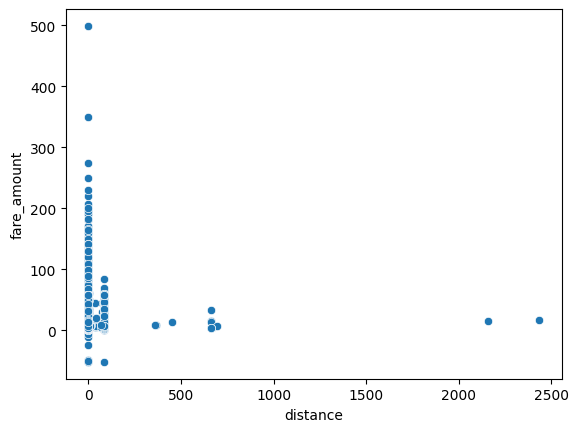

In [23]:
sns.scatterplot(x = 'distance', y = 'fare_amount', data = df)

In [24]:
df = df[(df['distance'] <= 300) & (df['fare_amount'] <= 500)]

<Axes: xlabel='distance', ylabel='fare_amount'>

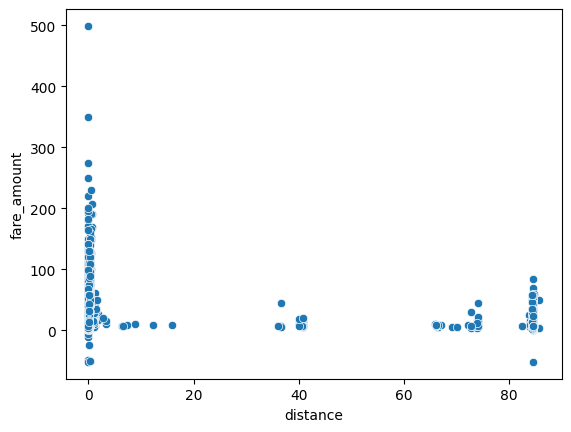

In [25]:
sns.scatterplot(x = 'distance', y = 'fare_amount', data = df)

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x = df.drop('fare_amount', axis = 1)
y = df['fare_amount']

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.2, random_state=42)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import root_mean_squared_error, r2_score
rmse = root_mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)
print(rmse)
print(r2)

9.575521699720982
0.0007940389695969552


In [29]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import root_mean_squared_error, r2_score
rmse = root_mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)
print(rmse)
print(r2)

5.42542854393285
0.6792266922153234
